# 06 — Análisis de estructura del diseño

**Objetivo**: evaluar la **estructura factorial** del diseño experimental implícito en los datos, diagnosticando el balance entre celdas, la existencia de combinaciones vacías y las implicaciones para la estrategia analítica posterior.

### ¿Por qué este notebook?

Antes de ejecutar cualquier modelo estadístico (ANOVA, GLMM), es imprescindible comprender la estructura del diseño:

1. **Balance del diseño**: un diseño desbalanceado invalida el uso de sumas de cuadrados Tipo I y obliga a justificar la elección entre Tipo II y Tipo III.
2. **Celdas vacías**: si existen combinaciones factoriales sin observaciones, las interacciones de orden superior no son estimables y los modelos pueden colapsar.
3. **Robustez inferencial**: la interpretación de efectos principales e interacciones depende críticamente de la estructura del diseño.

### Pipeline

| Notebook | Fase | Estado |
|:---|:---|:---|
| 01 | Limpieza de negocio + Formato_del_Juego | ✅ |
| 02 | Selección de VD | ✅ |
| 03 | Métricas derivadas | ✅ |
| 04 | Limpieza estadística | ✅ |
| 05 | Diccionario de métricas | ✅ |
| **06** | **Estructura del diseño** | 🔄 ← este notebook |

### Variables independientes (VI)

| Variable | Tipo | Descripción |
|:---|:---|:---|
| `Formato_del_Juego` | VI tarea (2 niveles: SSG, LSG) | Formato del juego reducido o ampliado |
| `Polaridad` | VI tarea (2 niveles) | Dirección del juego |
| `Equilibrio` | VI tarea (2 niveles) | Igualdad numérica entre equipos |
| `GrupoEdad` | VI contexto (5 niveles) | Categoría de edad del equipo |
| `NombreCorrecto` | Contexto (12 niveles) | Equipo/categoría específica |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# ── Estilo global ──
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})

PALETTE = {
    "azul":    "#1565C0",
    "rojo":    "#C62828",
    "verde":   "#2E7D32",
    "naranja": "#EF6C00",
    "gris":    "#616161",
    "morado":  "#6A1B9A",
}

# ── Variables del diseño ──
VI_TAREA = ["Formato_del_Juego", "Polaridad", "Equilibrio"]
VI_CONTEXTO = ["GrupoEdad", "NombreCorrecto"]
VI_ALL = VI_TAREA + VI_CONTEXTO

# ── Carga ──
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
N = len(df)
print(f"✅ Matriz_V3 cargada — {N:,} filas × {df.shape[1]} columnas")
print(f"\nVI de tarea:    {VI_TAREA}")
print(f"VI de contexto: {VI_CONTEXTO}")

✅ Matriz_V3 cargada — 3,179 filas × 18 columnas

VI de tarea:    ['Formato_del_Juego', 'Polaridad', 'Equilibrio']
VI de contexto: ['GrupoEdad', 'NombreCorrecto']


---

## 1 · Distribución marginal de cada VI

Se analiza la frecuencia absoluta y relativa de cada nivel de las 3 variables independientes de tarea. Un diseño balanceado debería mostrar proporciones similares entre niveles de cada factor.

In [2]:
# ── 1.1 Tablas de frecuencia marginal ──
print("═" * 65)
print("  DISTRIBUCIÓN MARGINAL — Variables independientes de tarea")
print("═" * 65)

for vi in VI_TAREA:
    vc = df[vi].value_counts()
    pct = df[vi].value_counts(normalize=True) * 100
    tabla = pd.DataFrame({"N": vc, "%": pct.round(1)})
    tabla.index.name = vi
    print(f"\n{'─'*60}")
    print(f"  {vi}  ({df[vi].nunique()} niveles)")
    print(f"{'─'*60}")
    for nivel in tabla.index:
        print(f"    {str(nivel):25s}  {tabla.loc[nivel, 'N']:>5,}  ({tabla.loc[nivel, '%']:>5.1f}%)")
    
    # Ratio de desbalance: max/min
    ratio = vc.max() / vc.min()
    print(f"  Ratio max/min: {ratio:.2f}  {'✅ Equilibrado' if ratio < 1.5 else '⚠️ Desbalance moderado' if ratio < 3 else '🔴 Desbalance severo'}")

═════════════════════════════════════════════════════════════════
  DISTRIBUCIÓN MARGINAL — Variables independientes de tarea
═════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  Formato_del_Juego  (2 niveles)
────────────────────────────────────────────────────────────
    LSG                        1,637  ( 51.5%)
    SSG                        1,542  ( 48.5%)
  Ratio max/min: 1.06  ✅ Equilibrado

────────────────────────────────────────────────────────────
  Polaridad  (2 niveles)
────────────────────────────────────────────────────────────
    Polarizado                 2,530  ( 79.6%)
    No_polarizado                649  ( 20.4%)
  Ratio max/min: 3.90  🔴 Desbalance severo

────────────────────────────────────────────────────────────
  Equilibrio  (2 niveles)
────────────────────────────────────────────────────────────
    Equilibrio                 2,381  ( 74.9%)
    Desequilibrio                798  ( 

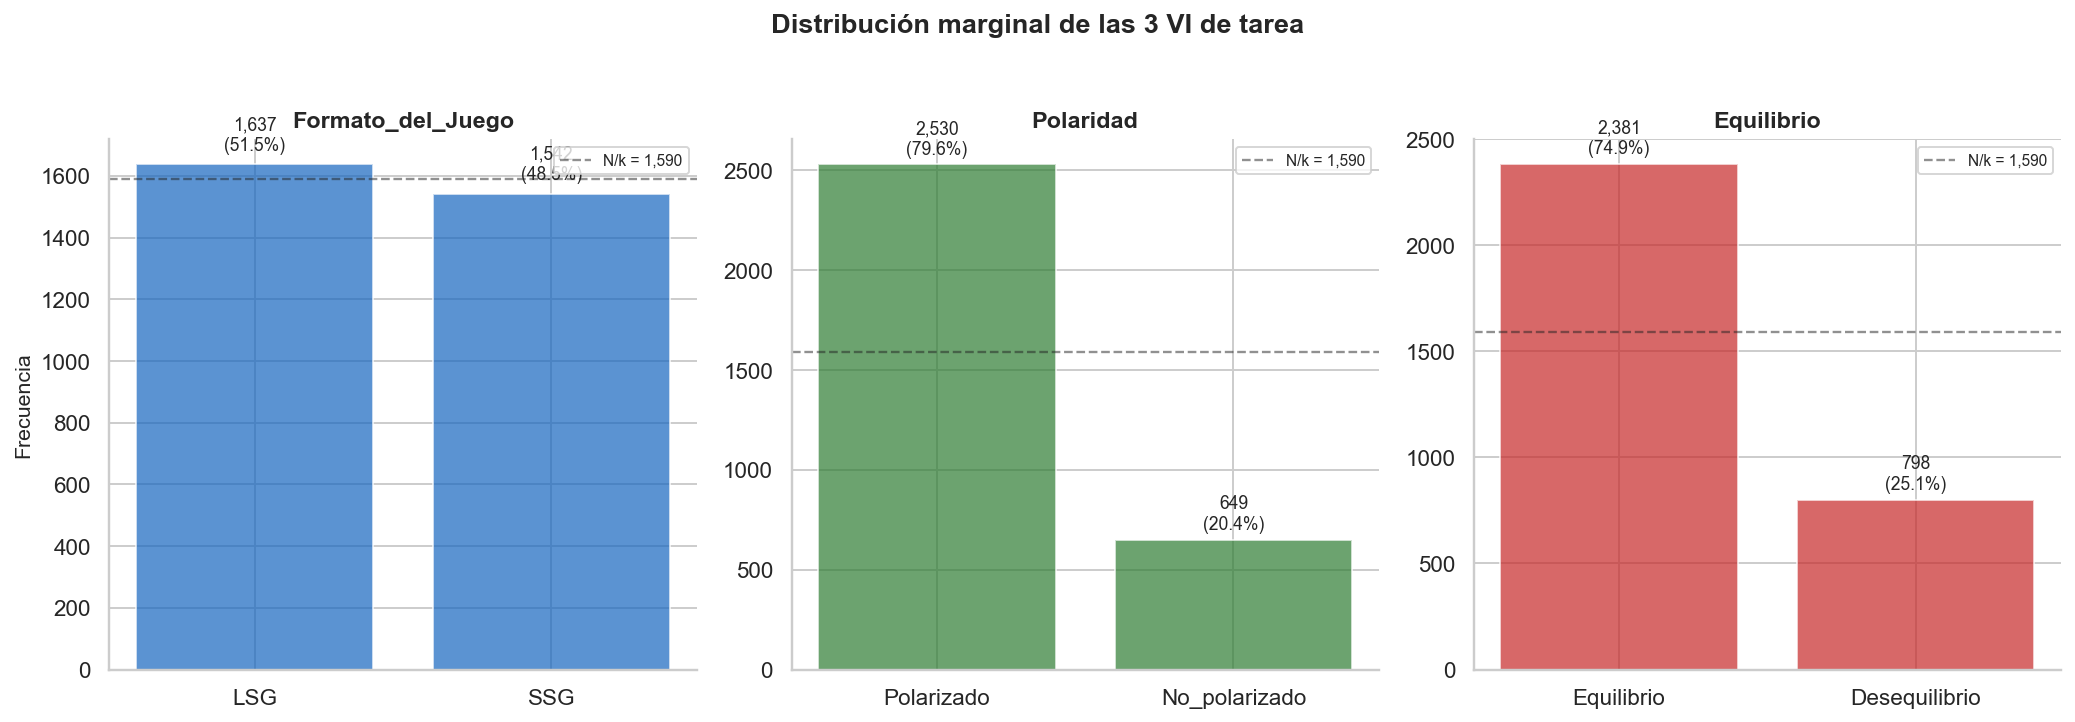

In [3]:
# ── 1.2 Barplots de distribución marginal ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores = [PALETTE["azul"], PALETTE["verde"], PALETTE["rojo"]]

for ax, vi, color in zip(axes, VI_TAREA, colores):
    vc = df[vi].value_counts()
    bars = ax.bar(vc.index, vc.values, color=color, alpha=0.7, edgecolor="white")
    
    # Etiquetas de frecuencia
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + N * 0.01,
                f"{val:,}\n({val/N*100:.1f}%)", ha="center", va="bottom", fontsize=9)
    
    # Línea de referencia: N/k (distribución uniforme)
    k = df[vi].nunique()
    ax.axhline(N / k, color="#222", ls="--", lw=1.2, alpha=0.5,
               label=f"N/k = {N/k:,.0f}")
    
    ax.set_title(vi, fontsize=12, fontweight="bold")
    ax.set_ylabel("Frecuencia" if ax == axes[0] else "")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribución marginal de las 3 VI de tarea",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

---

## 2 · Tablas de contingencia cruzadas (diseño factorial)

Se generan las 3 tablas de contingencia posibles entre pares de VI de tarea, y la tabla factorial completa 3-way. El objetivo es detectar **celdas vacías** y evaluar el **grado de ortogonalidad** entre factores.

In [4]:
# ── 2.1–2.3 Tablas de contingencia 2-way ──
pares = list(combinations(VI_TAREA, 2))

print("═" * 65)
print("  TABLAS DE CONTINGENCIA 2-WAY")
print("═" * 65)

for i, (vi_a, vi_b) in enumerate(pares, 1):
    ct = pd.crosstab(df[vi_a], df[vi_b], margins=True, margins_name="Total")
    ct_pct = pd.crosstab(df[vi_a], df[vi_b], normalize="all") * 100
    
    n_celdas = df[vi_a].nunique() * df[vi_b].nunique()
    n_vacias = (ct.iloc[:-1, :-1] == 0).sum().sum()
    
    print(f"\n{'─'*65}")
    print(f"  2.{i}  {vi_a} × {vi_b}")
    print(f"{'─'*65}")
    print(f"  Combinaciones posibles: {n_celdas}")
    print(f"  Celdas vacías:          {n_vacias}  {'✅' if n_vacias == 0 else '⚠️'}")
    print()
    
    # Tabla con frecuencias absolutas
    display(ct)
    
    # Ratio max/min dentro de las celdas (excluyendo marginales)
    vals = ct.iloc[:-1, :-1].values.flatten()
    vals_nonzero = vals[vals > 0]
    if len(vals_nonzero) > 1:
        ratio = vals_nonzero.max() / vals_nonzero.min()
        print(f"  Ratio max/min entre celdas: {ratio:.2f}")
        print(f"  CV del tamaño de celda:     {np.std(vals_nonzero)/np.mean(vals_nonzero)*100:.1f}%")

═════════════════════════════════════════════════════════════════
  TABLAS DE CONTINGENCIA 2-WAY
═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  2.1  Formato_del_Juego × Polaridad
─────────────────────────────────────────────────────────────────
  Combinaciones posibles: 4
  Celdas vacías:          0  ✅



Polaridad,No_polarizado,Polarizado,Total
Formato_del_Juego,,,
LSG,136,1501,1637
SSG,513,1029,1542
Total,649,2530,3179


  Ratio max/min entre celdas: 11.04
  CV del tamaño de celda:     65.0%

─────────────────────────────────────────────────────────────────
  2.2  Formato_del_Juego × Equilibrio
─────────────────────────────────────────────────────────────────
  Combinaciones posibles: 4
  Celdas vacías:          0  ✅



Equilibrio,Desequilibrio,Equilibrio,Total
Formato_del_Juego,,,
LSG,146,1491,1637
SSG,652,890,1542
Total,798,2381,3179


  Ratio max/min entre celdas: 10.21
  CV del tamaño de celda:     60.8%

─────────────────────────────────────────────────────────────────
  2.3  Polaridad × Equilibrio
─────────────────────────────────────────────────────────────────
  Combinaciones posibles: 4
  Celdas vacías:          0  ✅



Equilibrio,Desequilibrio,Equilibrio,Total
Polaridad,,,
No_polarizado,472,177,649
Polarizado,326,2204,2530
Total,798,2381,3179


  Ratio max/min entre celdas: 12.45
  CV del tamaño de celda:     103.2%


In [5]:
# ── 2.4 Tabla de contingencia 3-way completa ──
print("═" * 70)
print("  TABLA FACTORIAL COMPLETA: Formato_del_Juego × Polaridad × Equilibrio")
print("═" * 70)

# Calcular frecuencias por celda factorial
ct_3way = (
    df.groupby(VI_TAREA)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)

# Combinaciones posibles vs observadas
niveles_por_vi = [df[vi].nunique() for vi in VI_TAREA]
n_comb_posibles = np.prod(niveles_por_vi)
n_comb_observadas = len(ct_3way)
n_comb_vacias = n_comb_posibles - n_comb_observadas

print(f"\n  Niveles por factor: {dict(zip(VI_TAREA, niveles_por_vi))}")
print(f"  Combinaciones posibles:   {n_comb_posibles}")
print(f"  Combinaciones observadas: {n_comb_observadas}")
print(f"  Celdas vacías:            {n_comb_vacias}  "
      f"({n_comb_vacias/n_comb_posibles*100:.1f}%)  "
      f"{'✅ Diseño completo' if n_comb_vacias == 0 else '⚠️ Diseño incompleto'}")

print(f"\n{'─'*70}")
print(f"  Frecuencias por celda factorial")
print(f"{'─'*70}")
display(ct_3way)

# Estadísticos del tamaño de celda
ns = ct_3way["N"].values
print(f"\n  Estadísticos del tamaño de celda (N por combinación):")
print(f"    Media:    {np.mean(ns):>8.1f}")
print(f"    SD:       {np.std(ns):>8.1f}")
print(f"    Min:      {np.min(ns):>8}")
print(f"    Max:      {np.max(ns):>8}")
print(f"    CV:       {np.std(ns)/np.mean(ns)*100:>7.1f}%")
print(f"    Ratio max/min: {np.max(ns)/np.min(ns):.2f}")

══════════════════════════════════════════════════════════════════════
  TABLA FACTORIAL COMPLETA: Formato_del_Juego × Polaridad × Equilibrio
══════════════════════════════════════════════════════════════════════

  Niveles por factor: {'Formato_del_Juego': 2, 'Polaridad': 2, 'Equilibrio': 2}
  Combinaciones posibles:   8
  Combinaciones observadas: 8
  Celdas vacías:            0  (0.0%)  ✅ Diseño completo

──────────────────────────────────────────────────────────────────────
  Frecuencias por celda factorial
──────────────────────────────────────────────────────────────────────


,Formato_del_Juego,Polaridad,Equilibrio,N
3,LSG,Polarizado,Equilibrio,1436
7,SSG,Polarizado,Equilibrio,768
4,SSG,No_polarizado,Desequilibrio,391
6,SSG,Polarizado,Desequilibrio,261
5,SSG,No_polarizado,Equilibrio,122
0,LSG,No_polarizado,Desequilibrio,81
2,LSG,Polarizado,Desequilibrio,65
1,LSG,No_polarizado,Equilibrio,55



  Estadísticos del tamaño de celda (N por combinación):
    Media:       397.4
    SD:          452.5
    Min:            55
    Max:          1436
    CV:         113.9%
    Ratio max/min: 26.11


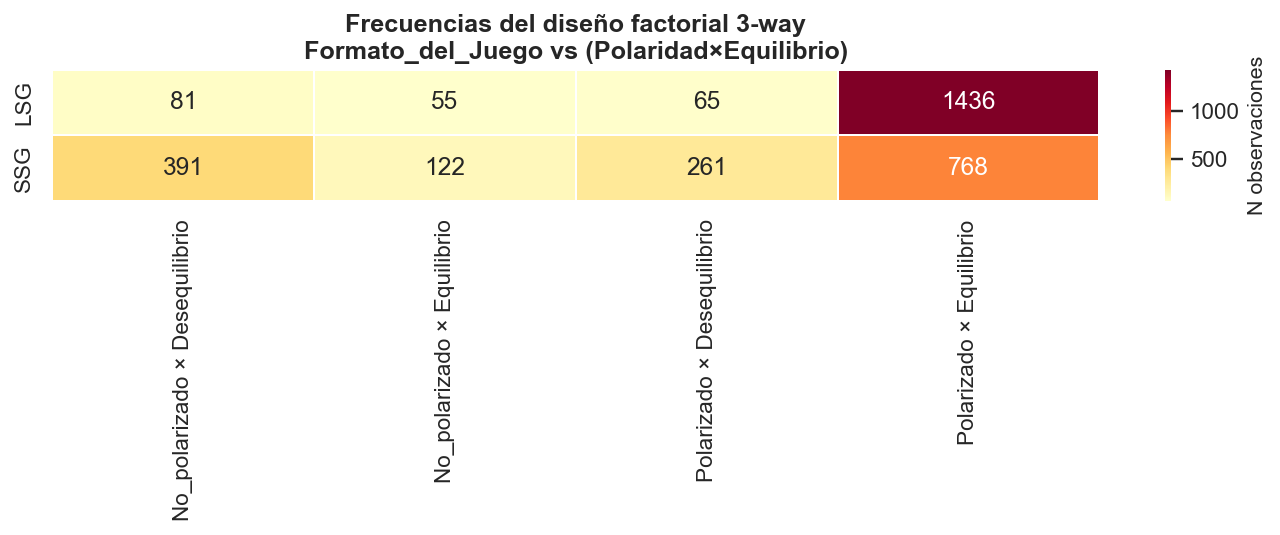

In [6]:
# ── 2.4b Heatmap de la tabla 3-way (pivotada para visualización) ──
ct_pivot = ct_3way.copy()
ct_pivot["Fila"] = ct_pivot["Formato_del_Juego"]
ct_pivot["Columna"] = ct_pivot["Polaridad"] + " × " + ct_pivot["Equilibrio"]

heatmap_data = ct_pivot.pivot_table(index="Fila", columns="Columna", values="N",
                                     aggfunc="sum", fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=1, linecolor="white", ax=ax,
            cbar_kws={"label": "N observaciones"})
ax.set_title("Frecuencias del diseño factorial 3-way\nFormato_del_Juego vs (Polaridad×Equilibrio)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---

## 3 · Inclusión de GrupoEdad y NombreCorrecto

Se analiza la relación entre la variable de **contexto** (`GrupoEdad`, `NombreCorrecto`) y las 3 VI de tarea. El objetivo es evaluar:

1. Si todas las combinaciones factoriales se **replican** en todas las categorías de edad.
2. Si hay combinaciones **específicas** de ciertas categorías (diseño parcialmente anidado).
3. Si `GrupoEdad` y `NombreCorrecto` son redundantes o aportan información distinta.

In [7]:
# ── 3.1 Frecuencia por GrupoEdad ──
print("═" * 65)
print("  DISTRIBUCIÓN DE GrupoEdad")
print("═" * 65)

vc_ge = df["GrupoEdad"].value_counts()
for nivel, n in vc_ge.items():
    print(f"    {str(nivel):25s}  {n:>5,}  ({n/N*100:>5.1f}%)")

print(f"\n  Ratio max/min: {vc_ge.max()/vc_ge.min():.2f}")

═════════════════════════════════════════════════════════════════
  DISTRIBUCIÓN DE GrupoEdad
═════════════════════════════════════════════════════════════════
    Neskak                       811  ( 25.5%)
    Juvenil                      771  ( 24.3%)
    Senior Masculino             653  ( 20.5%)
    Cadete                       579  ( 18.2%)
    Infantil                     365  ( 11.5%)

  Ratio max/min: 2.22


In [8]:
# ── 3.2 Frecuencia por NombreCorrecto ──
print("═" * 65)
print("  DISTRIBUCIÓN DE NombreCorrecto")
print("═" * 65)

vc_nc = df["NombreCorrecto"].value_counts()
for nivel, n in vc_nc.items():
    print(f"    {str(nivel):35s}  {n:>5,}  ({n/N*100:>5.1f}%)")

print(f"\n  Ratio max/min: {vc_nc.max()/vc_nc.min():.2f}")

═════════════════════════════════════════════════════════════════
  DISTRIBUCIÓN DE NombreCorrecto
═════════════════════════════════════════════════════════════════
    EASO                                   440  ( 13.8%)
    Neskak A                               334  ( 10.5%)
    Juvenil División de Honor              331  ( 10.4%)
    Neskak B                               325  ( 10.2%)
    Cadete Txiki                           298  (  9.4%)
    Cadete Vasca                           281  (  8.8%)
    Real Sociedad C                        277  (  8.7%)
    SANSE                                  274  (  8.6%)
    Infantil Txiki                         255  (  8.0%)
    Neskak C                               152  (  4.8%)
    Infantil Handi                         110  (  3.5%)
    Real Sociedad                          102  (  3.2%)

  Ratio max/min: 4.31


In [9]:
# ── 3.3 Relación GrupoEdad ↔ NombreCorrecto ──
print("═" * 65)
print("  RELACIÓN GrupoEdad ↔ NombreCorrecto")
print("═" * 65)

ct_ge_nc = pd.crosstab(df["NombreCorrecto"], df["GrupoEdad"])
display(ct_ge_nc)

# ¿Relación determinista? Cada NombreCorrecto mapea a un único GrupoEdad
mapeo = df.groupby("NombreCorrecto")["GrupoEdad"].nunique()
es_determinista = (mapeo == 1).all()
print(f"\n  ¿Mapeo determinista (1:1)? {'✅ Sí' if es_determinista else '❌ No'}")
print(f"  → NombreCorrecto está ANIDADO dentro de GrupoEdad.")
print(f"  → No deben incluirse ambos como factores cruzados en un mismo modelo.")
print(f"  → GrupoEdad = factor de agrupación; NombreCorrecto = nivel jerárquico inferior.")

═════════════════════════════════════════════════════════════════
  RELACIÓN GrupoEdad ↔ NombreCorrecto
═════════════════════════════════════════════════════════════════


GrupoEdad,Cadete,Infantil,Juvenil,Neskak,Senior Masculino
NombreCorrecto,,,,,
Cadete Txiki,298,0,0,0,0
Cadete Vasca,281,0,0,0,0
EASO,0,0,440,0,0
Infantil Handi,0,110,0,0,0
Infantil Txiki,0,255,0,0,0
Juvenil División de Honor,0,0,331,0,0
Neskak A,0,0,0,334,0
Neskak B,0,0,0,325,0
Neskak C,0,0,0,152,0



  ¿Mapeo determinista (1:1)? ✅ Sí
  → NombreCorrecto está ANIDADO dentro de GrupoEdad.
  → No deben incluirse ambos como factores cruzados en un mismo modelo.
  → GrupoEdad = factor de agrupación; NombreCorrecto = nivel jerárquico inferior.


In [10]:
# ── 3.4 Cruce GrupoEdad × cada VI de tarea ──
print("═" * 70)
print("  TABLAS DE CONTINGENCIA: GrupoEdad × VI de tarea")
print("═" * 70)

for vi in VI_TAREA:
    ct = pd.crosstab(df["GrupoEdad"], df[vi], margins=True, margins_name="Total")
    n_vacias = (ct.iloc[:-1, :-1] == 0).sum().sum()
    
    print(f"\n{'─'*65}")
    print(f"  GrupoEdad × {vi}")
    print(f"{'─'*65}")
    display(ct)
    print(f"  Celdas vacías: {n_vacias}  {'✅' if n_vacias == 0 else '⚠️'}")

══════════════════════════════════════════════════════════════════════
  TABLAS DE CONTINGENCIA: GrupoEdad × VI de tarea
══════════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  GrupoEdad × Formato_del_Juego
─────────────────────────────────────────────────────────────────


Formato_del_Juego,LSG,SSG,Total
GrupoEdad,,,
Cadete,267,312,579
Infantil,210,155,365
Juvenil,284,487,771
Neskak,600,211,811
Senior Masculino,276,377,653
Total,1637,1542,3179


  Celdas vacías: 0  ✅

─────────────────────────────────────────────────────────────────
  GrupoEdad × Polaridad
─────────────────────────────────────────────────────────────────


Polaridad,No_polarizado,Polarizado,Total
GrupoEdad,,,
Cadete,125,454,579
Infantil,59,306,365
Juvenil,148,623,771
Neskak,164,647,811
Senior Masculino,153,500,653
Total,649,2530,3179


  Celdas vacías: 0  ✅

─────────────────────────────────────────────────────────────────
  GrupoEdad × Equilibrio
─────────────────────────────────────────────────────────────────


Equilibrio,Desequilibrio,Equilibrio,Total
GrupoEdad,,,
Cadete,197,382,579
Infantil,59,306,365
Juvenil,109,662,771
Neskak,196,615,811
Senior Masculino,237,416,653
Total,798,2381,3179


  Celdas vacías: 0  ✅


In [11]:
# ── 3.5 Tabla 4-way: GrupoEdad × diseño factorial 3-way ──
print("═" * 70)
print("  COBERTURA FACTORIAL POR GrupoEdad")
print("═" * 70)

ct_4way = df.groupby(["GrupoEdad"] + VI_TAREA).size().reset_index(name="N")

# Para cada GrupoEdad, ¿cuántas de las 8 combinaciones están representadas?
resumen_cobertura = []
for ge in sorted(df["GrupoEdad"].unique()):
    sub = ct_4way[ct_4way["GrupoEdad"] == ge]
    n_obs = sub["N"].sum()
    n_comb = len(sub)
    n_vacias = n_comb_posibles - n_comb
    resumen_cobertura.append({
        "GrupoEdad": ge,
        "N total": n_obs,
        "Combinaciones observadas": n_comb,
        "Combinaciones posibles": n_comb_posibles,
        "Celdas vacías": n_vacias,
        "Cobertura (%)": round(n_comb / n_comb_posibles * 100, 1),
        "N medio/celda": round(n_obs / n_comb, 1) if n_comb > 0 else 0,
    })

df_cobertura = pd.DataFrame(resumen_cobertura)
display(df_cobertura)

# ¿Diseño completo en todas las categorías?
todas_completas = (df_cobertura["Celdas vacías"] == 0).all()
print(f"\n  ¿Todas las categorías cubren las {n_comb_posibles} combinaciones? "
      f"{'✅ Sí' if todas_completas else '⚠️ No'}")

if not todas_completas:
    vacias = df_cobertura[df_cobertura["Celdas vacías"] > 0]
    for _, row in vacias.iterrows():
        print(f"    {row['GrupoEdad']}: {row['Celdas vacías']} celdas vacías "
              f"(cobertura {row['Cobertura (%)']}%)")

══════════════════════════════════════════════════════════════════════
  COBERTURA FACTORIAL POR GrupoEdad
══════════════════════════════════════════════════════════════════════


,GrupoEdad,N total,Combinaciones observadas,Combinaciones posibles,Celdas vacías,Cobertura (%),N medio/celda
0,Cadete,579,5,8,3,62.5,115.8
1,Infantil,365,7,8,1,87.5,52.1
2,Juvenil,771,5,8,3,62.5,154.2
3,Neskak,811,8,8,0,100.0,101.4
4,Senior Masculino,653,7,8,1,87.5,93.3



  ¿Todas las categorías cubren las 8 combinaciones? ⚠️ No
    Cadete: 3 celdas vacías (cobertura 62.5%)
    Infantil: 1 celdas vacías (cobertura 87.5%)
    Juvenil: 3 celdas vacías (cobertura 62.5%)
    Senior Masculino: 1 celdas vacías (cobertura 87.5%)


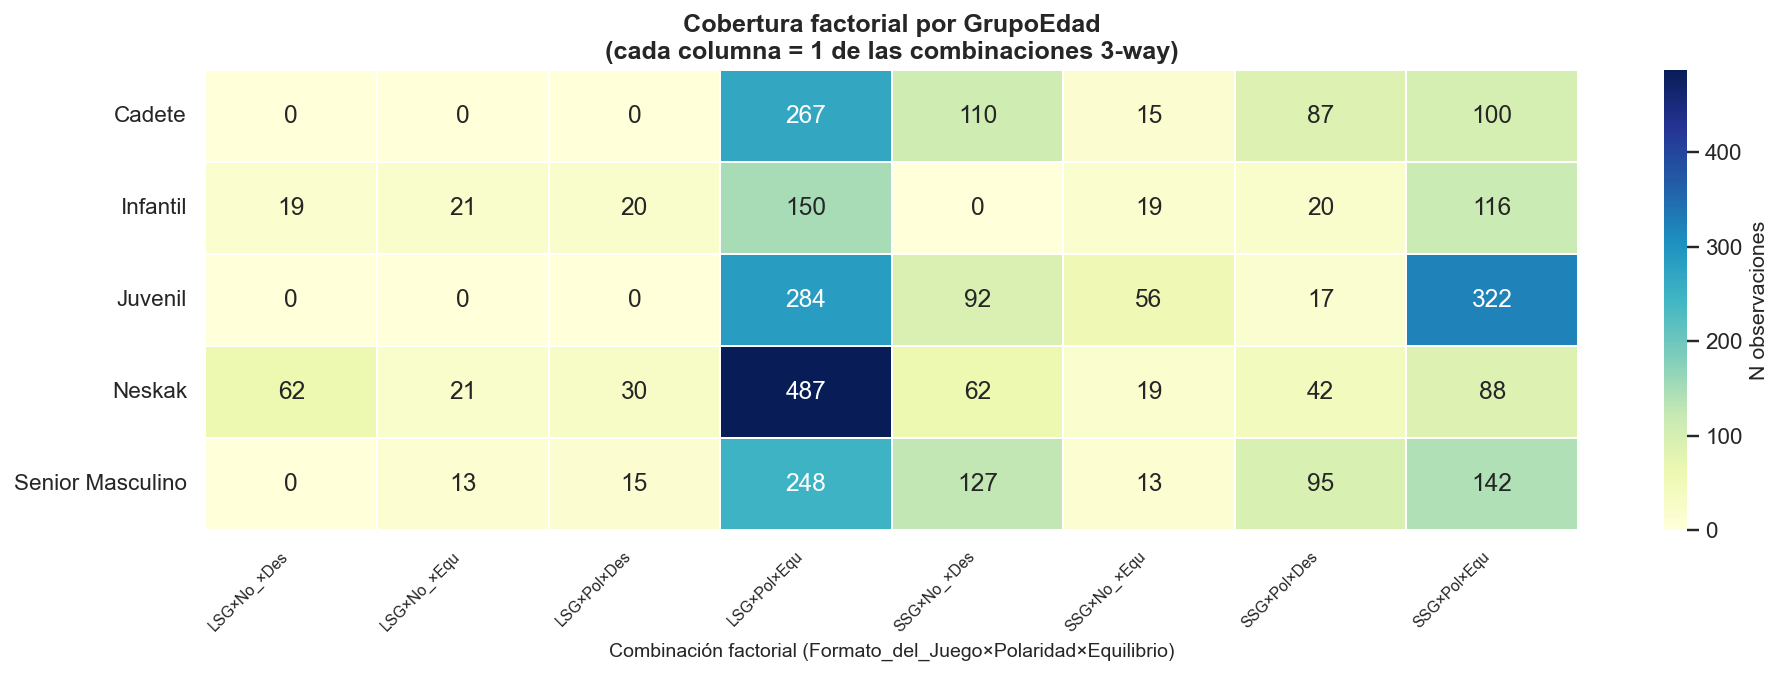


  Celdas con N=0 en el heatmap: 8/40 (20.0%)


In [12]:
# ── 3.6 Visualización: heatmap de cobertura por GrupoEdad ──
# Crear etiqueta de celda factorial para las 8 combinaciones
df_temp = df.copy()
df_temp["Celda_3way"] = (df_temp["Formato_del_Juego"] + "×" +
                          df_temp["Polaridad"].str[:3] + "×" +
                          df_temp["Equilibrio"].str[:3])

ct_heat = pd.crosstab(df_temp["GrupoEdad"], df_temp["Celda_3way"])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(ct_heat, annot=True, fmt="d", cmap="YlGnBu",
            linewidths=0.8, linecolor="white", ax=ax,
            cbar_kws={"label": "N observaciones"})
ax.set_title("Cobertura factorial por GrupoEdad\n(cada columna = 1 de las combinaciones 3-way)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Combinación factorial (Formato_del_Juego×Polaridad×Equilibrio)", fontsize=10)
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

n_ceros_heatmap = (ct_heat == 0).sum().sum()
n_total_heatmap = ct_heat.shape[0] * ct_heat.shape[1]
print(f"\n  Celdas con N=0 en el heatmap: {n_ceros_heatmap}/{n_total_heatmap} "
      f"({n_ceros_heatmap/n_total_heatmap*100:.1f}%)")

---

## 4 · Evaluación formal del balance

Se cuantifica el grado de desbalance del diseño factorial utilizando métricas estándar. Un diseño **perfectamente balanceado** tiene todas las celdas con el mismo $N$; un diseño **desbalanceado** presenta variabilidad significativa.

In [13]:
# ── 4.1 Balance del diseño factorial 3-way (sin GrupoEdad) ──
print("═" * 70)
print("  EVALUACIÓN DEL BALANCE — Diseño 3-way")
print("═" * 70)

ns_3way = ct_3way["N"].values
n_esperado = N / n_comb_posibles

print(f"\n  Total de observaciones:        {N:,}")
print(f"  Celdas factoriales:            {n_comb_posibles}")
print(f"  N esperado (balanceado):       {n_esperado:.1f}")
print(f"\n  {'─'*50}")
print(f"  Estadísticos del tamaño de celda:")
print(f"    Media:        {np.mean(ns_3way):>8.1f}")
print(f"    SD:           {np.std(ns_3way, ddof=1):>8.1f}")
print(f"    Min:          {np.min(ns_3way):>8}")
print(f"    Max:          {np.max(ns_3way):>8}")
print(f"    Rango:        {np.max(ns_3way) - np.min(ns_3way):>8}")
print(f"    CV:           {np.std(ns_3way, ddof=1)/np.mean(ns_3way)*100:>7.1f}%")
print(f"    Ratio max/min:{np.max(ns_3way)/np.min(ns_3way):>7.2f}")

# Diagnóstico
cv_3way = np.std(ns_3way, ddof=1) / np.mean(ns_3way) * 100
if cv_3way < 5:
    diag = "✅ Diseño prácticamente balanceado (CV < 5%)"
elif cv_3way < 20:
    diag = "⚠️ Diseño moderadamente desbalanceado (5% < CV < 20%)"
else:
    diag = "🔴 Diseño severamente desbalanceado (CV > 20%)"

print(f"\n  DIAGNÓSTICO: {diag}")

══════════════════════════════════════════════════════════════════════
  EVALUACIÓN DEL BALANCE — Diseño 3-way
══════════════════════════════════════════════════════════════════════

  Total de observaciones:        3,179
  Celdas factoriales:            8
  N esperado (balanceado):       397.4

  ──────────────────────────────────────────────────
  Estadísticos del tamaño de celda:
    Media:           397.4
    SD:              483.8
    Min:                55
    Max:              1436
    Rango:            1381
    CV:             121.7%
    Ratio max/min:  26.11

  DIAGNÓSTICO: 🔴 Diseño severamente desbalanceado (CV > 20%)


In [14]:
# ── 4.2 Balance del diseño factorial 4-way (incluyendo GrupoEdad) ──
print("═" * 70)
print("  EVALUACIÓN DEL BALANCE — Diseño 4-way (con GrupoEdad)")
print("═" * 70)

n_comb_4way_posibles = n_comb_posibles * df["GrupoEdad"].nunique()
ns_4way = ct_4way["N"].values
n_comb_4way_obs = len(ct_4way)
n_comb_4way_vacias = n_comb_4way_posibles - n_comb_4way_obs

print(f"\n  Combinaciones posibles (3 VI × GrupoEdad):  {n_comb_4way_posibles}")
print(f"  Combinaciones observadas:                    {n_comb_4way_obs}")
print(f"  Celdas vacías:                               {n_comb_4way_vacias} "
      f"({n_comb_4way_vacias/n_comb_4way_posibles*100:.1f}%)")

print(f"\n  {'─'*50}")
print(f"  Estadísticos del tamaño de celda:")
print(f"    Media:        {np.mean(ns_4way):>8.1f}")
print(f"    SD:           {np.std(ns_4way, ddof=1):>8.1f}")
print(f"    Min:          {np.min(ns_4way):>8}")
print(f"    Max:          {np.max(ns_4way):>8}")
print(f"    CV:           {np.std(ns_4way, ddof=1)/np.mean(ns_4way)*100:>7.1f}%")
print(f"    Ratio max/min:{np.max(ns_4way)/np.min(ns_4way):>7.2f}")

# Diagnóstico
cv_4way = np.std(ns_4way, ddof=1) / np.mean(ns_4way) * 100
if n_comb_4way_vacias > 0:
    diag_4 = f"⚠️ Diseño incompleto ({n_comb_4way_vacias} celdas vacías) y desbalanceado (CV = {cv_4way:.1f}%)"
elif cv_4way < 5:
    diag_4 = "✅ Diseño completo y prácticamente balanceado"
elif cv_4way < 20:
    diag_4 = f"⚠️ Diseño completo pero moderadamente desbalanceado (CV = {cv_4way:.1f}%)"
else:
    diag_4 = f"🔴 Diseño completo pero severamente desbalanceado (CV = {cv_4way:.1f}%)"

print(f"\n  DIAGNÓSTICO: {diag_4}")

══════════════════════════════════════════════════════════════════════
  EVALUACIÓN DEL BALANCE — Diseño 4-way (con GrupoEdad)
══════════════════════════════════════════════════════════════════════

  Combinaciones posibles (3 VI × GrupoEdad):  40
  Combinaciones observadas:                    32
  Celdas vacías:                               8 (20.0%)

  ──────────────────────────────────────────────────
  Estadísticos del tamaño de celda:
    Media:            99.3
    SD:              111.1
    Min:                13
    Max:               487
    CV:             111.9%
    Ratio max/min:  37.46

  DIAGNÓSTICO: ⚠️ Diseño incompleto (8 celdas vacías) y desbalanceado (CV = 111.9%)


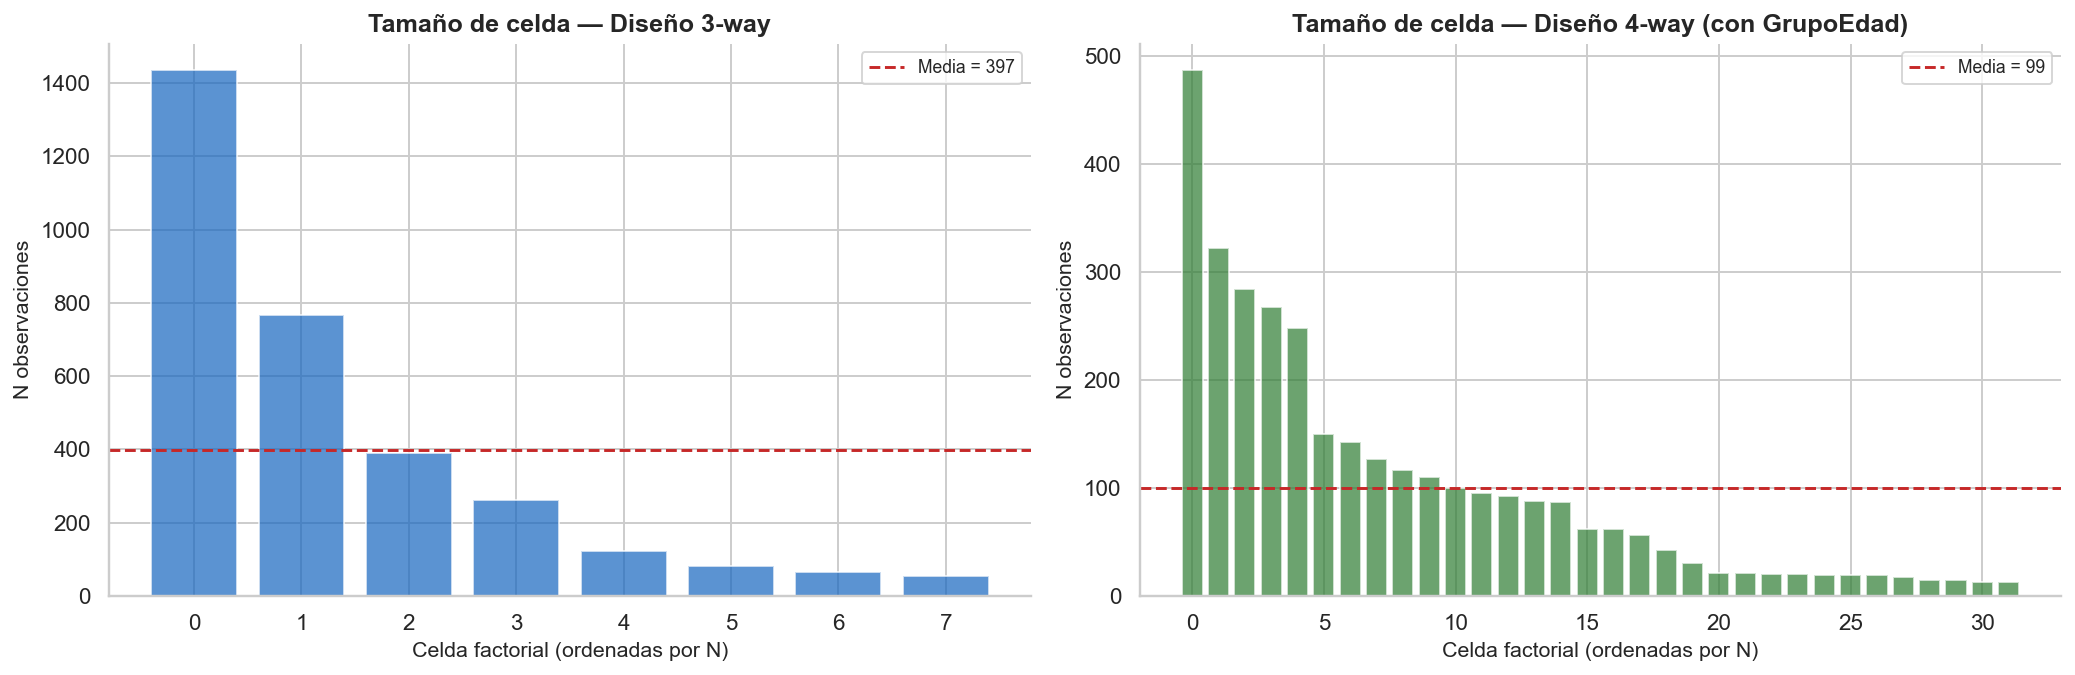

In [15]:
# ── 4.3 Visualización: distribución de tamaños de celda ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: 3-way
ax = axes[0]
ax.bar(range(len(ns_3way)), sorted(ns_3way, reverse=True),
       color=PALETTE["azul"], alpha=0.7, edgecolor="white")
ax.axhline(np.mean(ns_3way), color=PALETTE["rojo"], ls="--", lw=1.5,
           label=f"Media = {np.mean(ns_3way):.0f}")
ax.set_title("Tamaño de celda — Diseño 3-way", fontweight="bold")
ax.set_xlabel("Celda factorial (ordenadas por N)")
ax.set_ylabel("N observaciones")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Panel 2: 4-way (con GrupoEdad)
ax2 = axes[1]
ax2.bar(range(len(ns_4way)), sorted(ns_4way, reverse=True),
        color=PALETTE["verde"], alpha=0.7, edgecolor="white")
ax2.axhline(np.mean(ns_4way), color=PALETTE["rojo"], ls="--", lw=1.5,
            label=f"Media = {np.mean(ns_4way):.0f}")
ax2.set_title("Tamaño de celda — Diseño 4-way (con GrupoEdad)", fontweight="bold")
ax2.set_xlabel("Celda factorial (ordenadas por N)")
ax2.set_ylabel("N observaciones")
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
# ── 4.4 Resumen compacto del diagnóstico de balance ──
print("═" * 70)
print("  RESUMEN: DIAGNÓSTICO DE BALANCE DEL DISEÑO")
print("═" * 70)

resumen_balance = [
    {"Diseño": "3-way (VI tarea)",
     "Celdas posibles": n_comb_posibles,
     "Celdas observadas": n_comb_observadas,
     "Celdas vacías": n_comb_vacias,
     "N medio/celda": round(np.mean(ns_3way), 1),
     "CV (%)": round(cv_3way, 1),
     "Ratio max/min": round(np.max(ns_3way)/np.min(ns_3way), 2),
     "Completo": "✅" if n_comb_vacias == 0 else "❌",
     "Balanceado": "✅" if cv_3way < 5 else "⚠️" if cv_3way < 20 else "❌",
    },
    {"Diseño": "4-way (+ GrupoEdad)",
     "Celdas posibles": n_comb_4way_posibles,
     "Celdas observadas": n_comb_4way_obs,
     "Celdas vacías": n_comb_4way_vacias,
     "N medio/celda": round(np.mean(ns_4way), 1),
     "CV (%)": round(cv_4way, 1),
     "Ratio max/min": round(np.max(ns_4way)/np.min(ns_4way), 2),
     "Completo": "✅" if n_comb_4way_vacias == 0 else "❌",
     "Balanceado": "✅" if cv_4way < 5 else "⚠️" if cv_4way < 20 else "❌",
    },
]

df_balance = pd.DataFrame(resumen_balance)
display(df_balance.style.hide(axis="index"))

══════════════════════════════════════════════════════════════════════
  RESUMEN: DIAGNÓSTICO DE BALANCE DEL DISEÑO
══════════════════════════════════════════════════════════════════════


Diseño,Celdas posibles,Celdas observadas,Celdas vacías,N medio/celda,CV (%),Ratio max/min,Completo,Balanceado
3-way (VI tarea),8,8,0,397.400000,121.700000,26.110000,✅,❌
4-way (+ GrupoEdad),40,32,8,99.300000,111.900000,37.460000,❌,❌


---



## 5 · Implicaciones estadísticas



### 5.1. Sumas de cuadrados: Tipo I, II y III



En un ANOVA factorial, la descomposición de la variabilidad total en componentes atribuibles a cada factor depende del **tipo de sumas de cuadrados** (SS) utilizado. La elección entre Tipo I, II y III no es arbitraria: depende directamente de la **estructura del diseño**.



#### Tipo I — Sumas de cuadrados secuenciales



Cada factor se ajusta **tras controlar los factores introducidos antes** en la ecuación. El resultado depende del **orden** en que se especifiquen los factores.



- **Solo apropiado** en diseños **perfectamente balanceados** (todas las celdas con el mismo $N$), donde los tres tipos de SS coinciden.

- En diseños desbalanceados, los resultados cambian según el orden de los factores → **no recomendable**.



#### Tipo II — Sumas de cuadrados parciales (sin interacción)



Cada efecto principal se ajusta **controlando todos los demás efectos principales**, pero **sin considerar las interacciones**.



- Apropiado cuando se asume que **no existen interacciones** o cuando no se desea estimar interacciones.

- Más potente que el Tipo III cuando las interacciones son realmente nulas.

- **No recomendable** si:

  - Las interacciones son significativas (los efectos principales pierden interpretabilidad).

  - Existen celdas vacías (las estimaciones de efectos principales pueden estar sesgadas).



#### Tipo III — Sumas de cuadrados parciales (con interacción)



Cada efecto (principal o interacción) se ajusta **controlando todos los demás efectos**, incluidas las interacciones.



- El resultado es **invariante al orden** de los factores.

- Cada efecto se evalúa como la **reducción marginal de SS** al añadirlo al modelo completo.

- **Recomendable cuando**:

  - El diseño es **desbalanceado** (celdas con distinto $N$).

  - Se desean estimar **interacciones**.

  - Existen **celdas vacías** (aunque con precauciones).



---



### 5.2. ¿Qué significa Tipo III conceptualmente?



Las SS Tipo III responden a la pregunta:



> *¿Cuánta variabilidad explica este factor después de controlar todos los demás factores e interacciones del modelo?*



Formalmente, para un factor $A$ en un modelo con factores $A$, $B$ y su interacción $A \times B$:



$$

SS_{III}(A) = SS(A \mid B, A \times B)

$$



Es decir, el incremento en la suma de cuadrados del modelo al **añadir $A$** cuando $B$ y $A \times B$ ya están en el modelo. Esto garantiza que el efecto de $A$ no esté confundido con el desbalance de las otras variables.



En la práctica, las SS Tipo III requieren una **codificación de contrastes** apropiada. La más habitual es la codificación **suma** (o *deviation coding*), donde cada nivel del factor se compara con la media global, no con un nivel de referencia (como ocurre con la codificación *dummy* por defecto en muchos paquetes).



---



### 5.3. Aplicación a este diseño



#### Diseño 3-way (solo VI de tarea)



El diseño factorial formado por `Formato_del_Juego × Polaridad × Equilibrio` presenta las siguientes características:



- **8 combinaciones factoriales** ($2^3$).

- La completitud y el balance del diseño dependen de los datos observados y se reportan en la sección 4 de este notebook.

- `Formato_del_Juego` debería estar relativamente equilibrado (~50/50 entre SSG y LSG), pero `Polaridad` y `Equilibrio` pueden presentar desbalance.

- Si existe desbalance, las SS Tipo I dependerían del orden de los factores → **no recomendable**.

- Si se desean estimar interacciones entre las VI (esperable en ciencias del deporte, donde el efecto del formato de juego puede depender de la polaridad o el equilibrio), las SS Tipo II tampoco son apropiadas.



**→ Se recomienda SS Tipo III** para el análisis de las 3 VI de tarea.



#### Diseño 4-way (incluyendo GrupoEdad)



La inclusión de `GrupoEdad` amplía el diseño a $2^3 \times 5 = 40$ combinaciones posibles. La estructura observada puede presentar:



- **Celdas vacías** → diseño potencialmente **incompleto**.

- **Desbalance** entre combinaciones.



Las celdas vacías tienen consecuencias especialmente graves:



1. **Interacciones no estimables**: si una combinación de VI no se observa en un nivel de GrupoEdad, la interacción correspondiente no es estimable.

2. **Efectos principales sesgados**: en SS Tipo II, la ausencia de ortogonalidad entre factores puede sesgar las estimaciones.

3. **Contrastes no identificados**: con codificación suma y celdas vacías, la matriz de diseño puede no tener rango completo.



**→ Se recomienda SS Tipo III con precaución**, verificando que las interacciones de interés son estimables y que la matriz de diseño tiene rango suficiente. Las interacciones de orden ≥ 3 que involucren GrupoEdad deben evitarse.



---



### 5.4. Alternativa recomendada: GLMM



Dado que los datos presentan una **estructura jerárquica** (observaciones anidadas dentro de jugadores, dentro de equipos/categorías), un ANOVA clásico no captura la dependencia entre observaciones del mismo jugador. La alternativa natural es un **Modelo Lineal Generalizado Mixto** (GLMM):



- **Efectos fijos**: `Formato_del_Juego`, `Polaridad`, `Equilibrio` (y sus interacciones de orden ≤ 2).

- **Efectos aleatorios**: `Player Id` (intercepto aleatorio), anidado dentro de `NombreCorrecto`/`GrupoEdad`.

- **Sumas de cuadrados**: Tipo III (Wald chi-cuadrado o F con aproximación de Kenward-Roger).



El GLMM es robusto al desbalance y permite estimar efectos incluso con celdas de distinto tamaño, siempre que no estén completamente vacías.

---



## 6 · Conclusión metodológica



### Diagnóstico del diseño



El análisis de la estructura factorial revela las siguientes características del diseño experimental:



| Dimensión | Diseño 3-way (VI tarea) | Diseño 4-way (+ GrupoEdad) |
|:---|:---|:---|
| Factores | 3 × 2 niveles | 3 × 2 niveles + 1 × 5 niveles |
| Celdas posibles | 8 | 40 |
| Celdas observadas | *(ver sección 4)* | *(ver sección 4)* |
| Celdas vacías | *(ver sección 4)* | *(ver sección 4)* |



**Hallazgos clave:**



1. **Diseño 3-way con `Formato_del_Juego × Polaridad × Equilibrio`**: presenta $2^3 = 8$ combinaciones factoriales. El grado de completitud y balance se detalla en la sección 4.



2. **Diseño 4-way al incluir `GrupoEdad`**: amplía a $8 \times 5 = 40$ combinaciones posibles. El análisis de cobertura se presenta en la sección 3.5.



3. **Anidamiento confirmado**: `NombreCorrecto` está completamente anidado dentro de `GrupoEdad` (12 equipos → 5 categorías, mapeo 1:1). No deben cruzarse en un mismo modelo.



### Estrategia analítica recomendada



Con base en el diagnóstico anterior, se recomienda la siguiente estrategia para los análisis posteriores:



| Aspecto | Decisión | Justificación |
|:---|:---|:---|
| **Tipo de SS** | Tipo III | Diseño potencialmente desbalanceado → SS Tipo I dependen del orden; interacciones de interés → SS Tipo II no apropiadas |
| **Modelo** | GLMM | Estructura jerárquica (jugador → equipo → categoría); robustez al desbalance |
| **Efectos fijos** | 3 VI de tarea + GrupoEdad + interacciones ≤ orden 2 | Interacciones biologícamente plausibles |
| **Efectos aleatorios** | Player Id (intercepto) anidado en NombreCorrecto | Controla dependencia intra-sujeto y variabilidad inter-equipo |
| **Codificación** | Contrastes suma (*deviation coding*) | Necesaria para que SS Tipo III sean interpretables |



### Riesgos potenciales del desbalance



1. **Pérdida de potencia**: las celdas con pocas observaciones aportan estimaciones menos precisas, reduciendo la potencia para detectar efectos en esas combinaciones.

2. **Interacciones de orden superior**: si existen celdas vacías en el diseño 4-way, las interacciones que involucren GrupoEdad pueden no ser estimables. Se recomienda limitarse a interacciones de orden ≤ 2.

3. **Sensibilidad a outliers**: las celdas con bajo $N$ son más sensibles a observaciones extremas. Los diagnósticos de residuos serán especialmente importantes.

4. **Generalización limitada**: las conclusiones sobre combinaciones factoriales ausentes en ciertos grupos de edad no son extrapolables a toda la población.

5. **No ortogonalidad**: si los factores no son independientes entre sí, se refuerza la necesidad de SS Tipo III para aislar cada efecto.